(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB
None


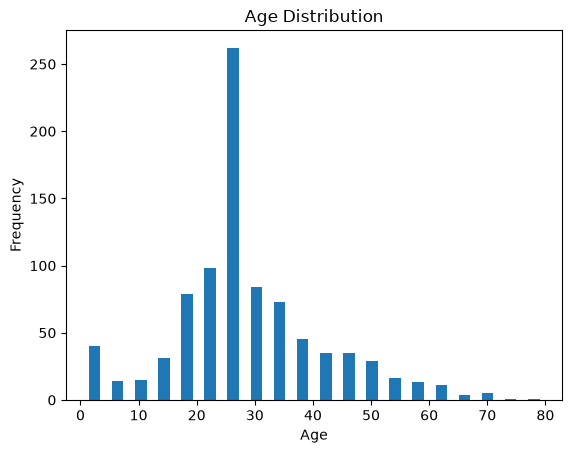

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

dftrain=pd.read_csv('train.csv')
dftest=pd.read_csv('test.csv')
print(dftrain.shape)
print(dftrain.isnull().sum()) 
 
dftrain.describe()

dftrain["Age"] = dftrain["Age"].fillna(dftrain["Age"].median())
dftrain["Embarked"] = dftrain["Embarked"].fillna(dftrain["Embarked"].mode()[0])
dftrain=dftrain.drop("Cabin", axis=1)

dftest["Age"] = dftest["Age"].fillna(dftest["Age"].median())
dftest["Fare"] = dftest["Fare"].fillna(dftest["Fare"].median())
dftest["Embarked"] = dftest["Embarked"].fillna(dftest["Embarked"].mode()[0])
dftest=dftest.drop("Cabin", axis=1)

print(dftrain.info())

# plot the age with survived and not survived
plt.hist(dftrain["Age"], bins=20,rwidth=0.5)
plt.title("Age Distribution")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


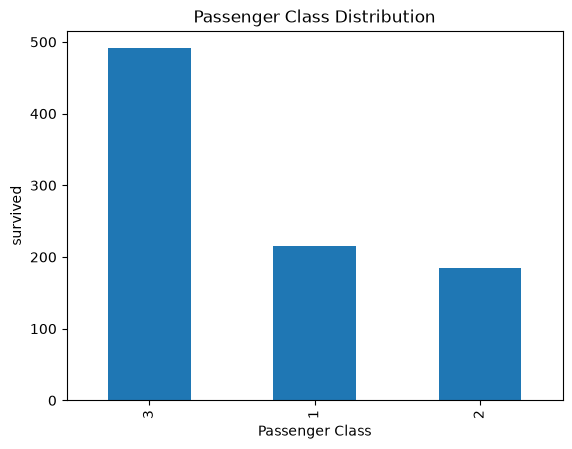

In [59]:
dftrain["Pclass"].value_counts().plot(kind="bar")
plt.xlabel("Passenger Class")
plt.ylabel("survived")

plt.title("Passenger Class Distribution")
plt.show()

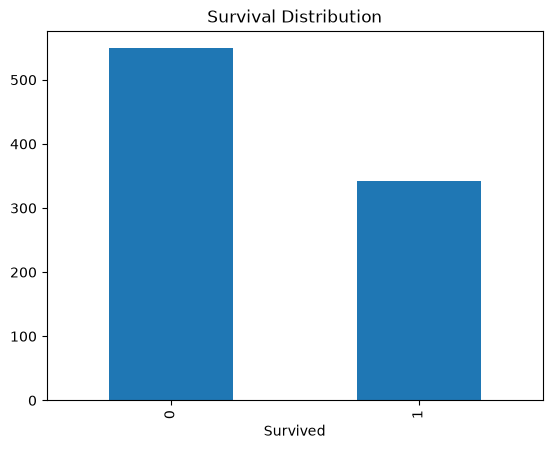

In [60]:
dftrain["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.show()

In [61]:
dftrain["FamilySize"] = dftrain["SibSp"] + dftrain["Parch"] + 1
dftest["FamilySize"] = dftest["SibSp"] + dftest["Parch"] + 1    

dftrain["isalone"] = np.where(dftrain["FamilySize"] == 1, 1, 0)
dftest["isalone"] = np.where(dftest["FamilySize"] == 1, 1, 0)
print(dftrain[["SibSp", "Parch", "FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [62]:
dftrain.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isalone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1


In [63]:
dftrain['Sex']=dftrain['Sex'].map({'male':0,'female':1})
dftrain['Embarked']=dftrain['Embarked'].map({'S':0,'C':1,'Q':2})
dftest['Sex']=dftest['Sex'].map({'male':0,'female':1})
dftest['Embarked']=dftest['Embarked'].map({'S':0,'C':1,'Q':2})

In [64]:
X = dftrain[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "isalone"
]]
xtest=dftest[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "isalone"
]]
y=dftrain['Survived']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
from sklearn.model_selection import cross_val_score

# using cross validation to evaluate the model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [68]:
randommodel = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)
scores=cross_val_score(randommodel, X_train, y_train, cv=5, scoring='accuracy')
print("Fold Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

randommodel.fit(X_train, y_train)

def predict_survival(model, xtest):
    return model.predict(xtest)

randompredictions=predict_survival(randommodel, xtest)

submission = pd.DataFrame({
    "PassengerId": dftest["PassengerId"],
    "Survived": randompredictions
})
print (submission.head())

submission.to_csv("submission.csv", index=False)


decisiontree = DecisionTreeClassifier(random_state=42)
logisticmodel = LogisticRegression(max_iter=1000, random_state=42)

gradientboost = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42)
scoresgradientboost = cross_val_score(gradientboost, X_train, y_train, cv=5, scoring='accuracy')
print("Fold Scores for Gradient Boosting:", scoresgradientboost)
print("Mean Accuracy for Gradient Boosting:", scoresgradientboost.mean())   


Fold Scores: [0.85314685 0.86013986 0.81690141 0.78873239 0.83802817]
Mean Accuracy: 0.8313897370235399
Std Dev: 0.0259752613381286
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Fold Scores for Gradient Boosting: [0.79020979 0.74825175 0.78873239 0.76760563 0.78169014]
Mean Accuracy for Gradient Boosting: 0.7752979414951245


In [ ]:

decisiontree.fit(X_train, y_train)
decisiontreepredictions = decisiontree.predict(X_test)
logisticmodel.fit(X_train, y_train)
logisticpredictions = logisticmodel.predict(X_test)
gradientboost.fit(X_train, y_train)
gradientpredictions = gradientboost.predict(X_test)

In [ ]:


decisiontreeaccuracy = accuracy_score(y_test, decisiontreepredictions)
print("Decision Tree Accuracy:", decisiontreeaccuracy)

logisticaccuracy = accuracy_score(y_test, logisticpredictions)
print("Logistic Regression Accuracy:", logisticaccuracy)       

gradientaccuracy = accuracy_score(y_test, gradientpredictions)
print("Gradient Boosting Accuracy:", gradientaccuracy)

Decision Tree Accuracy: 0.7877094972067039
Logistic Regression Accuracy: 0.7988826815642458
Gradient Boosting Accuracy: 0.7988826815642458


In [ ]:
def predict_survival(model, xtest):
    return model.predict(xtest)

In [ ]:


randompredictions=predict_survival(randommodel, xtest)

submission = pd.DataFrame({
    "PassengerId": dftest["PassengerId"],
    "Survived": randompredictions
})
print (submission.head())

submission.to_csv("submission.csv", index=False)



NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.